In [10]:
!pip install seaborn
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error


In [11]:
df = pd.read_csv("A1.3 NASA.csv")

print("Dimensiones del dataset:", df.shape)

print(df.head(15))


Dimensiones del dataset: (1503, 6)
    frecuencia  angulo  longitud  velocidad   espesor  presion
0          800     0.0    0.3048       71.3  0.002663  126.201
1         1000     0.0    0.3048       71.3  0.002663  125.201
2         1250     0.0    0.3048       71.3  0.002663  125.951
3         1600     0.0    0.3048       71.3  0.002663  127.591
4         2000     0.0    0.3048       71.3  0.002663  127.461
5         2500     0.0    0.3048       71.3  0.002663  125.571
6         3150     0.0    0.3048       71.3  0.002663  125.201
7         4000     0.0    0.3048       71.3  0.002663  123.061
8         5000     0.0    0.3048       71.3  0.002663  121.301
9         6300     0.0    0.3048       71.3  0.002663  119.541
10        8000     0.0    0.3048       71.3  0.002663  117.151
11       10000     0.0    0.3048       71.3  0.002663  115.391
12       12500     0.0    0.3048       71.3  0.002663  112.241
13       16000     0.0    0.3048       71.3  0.002663  108.721
14         500     0

In [12]:
# Variables predictoras (X) y variable objetivo (y)
X = df.drop("presion", axis=1)
y = df["presion"]

# Dividir en 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

print("Dimensiones entrenamiento:", X_train.shape, y_train.shape)
print("Dimensiones prueba:", X_test.shape, y_test.shape)
print("Suma total:", X_train.shape[0] + X_test.shape[0])


Dimensiones entrenamiento: (1052, 5) (1052,)
Dimensiones prueba: (451, 5) (451,)
Suma total: 1503


In [13]:
# Agregar constante (intercepto)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Ajustar modelo
modelo = sm.OLS(y_train, X_train_sm).fit()

print(modelo.summary())

# Mostrar p-values exactos
print("\nP-values exactos:")
print(modelo.pvalues)


                            OLS Regression Results                            
Dep. Variable:                presion   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     227.9
Date:                Thu, 21 Aug 2025   Prob (F-statistic):          1.38e-164
Time:                        07:59:35   Log-Likelihood:                -3138.0
No. Observations:                1052   AIC:                             6288.
Df Residuals:                    1046   BIC:                             6318.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.4778      0.651    203.367      0.0

In [14]:
# Variables con significancia estadística
significativas = modelo.pvalues[modelo.pvalues < 0.05]
print("Variables significativas:", significativas.index.tolist())

# Variable más importante: la de mayor valor absoluto de coeficiente estandarizado
coef_abs = modelo.params.abs().sort_values(ascending=False)
print("Variable más influyente (coeficiente absoluto):", coef_abs.index[1])  


Variables significativas: ['const', 'frecuencia', 'angulo', 'longitud', 'velocidad', 'espesor']
Variable más influyente (coeficiente absoluto): const


In [15]:
rse_train = np.sqrt(modelo.scale)
r2_train = modelo.rsquared

print(f"Residual Standard Error (train): {rse_train:.4f}")
print(f"R² (train): {r2_train:.4f}")

# Validación
y_pred_test = modelo.predict(X_test_sm)
rse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"Residual Standard Error (test): {rse_test:.4f}")
print(f"R² (test): {r2_test:.4f}")


Residual Standard Error (train): 4.7914
R² (train): 0.5214
Residual Standard Error (test): 4.8670
R² (test): 0.4983


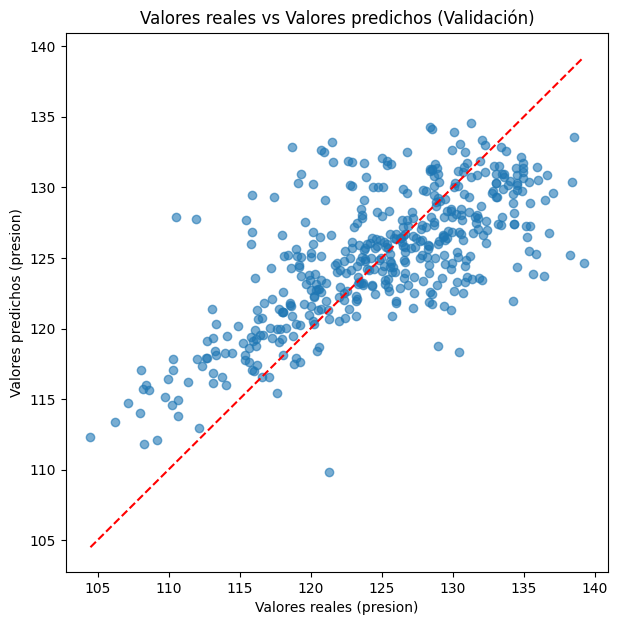

In [16]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Valores reales (presion)")
plt.ylabel("Valores predichos (presion)")
plt.title("Valores reales vs Valores predichos (Validación)")
plt.show()
